In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, recall_score, accuracy_score, precision_score, f1_score, roc_auc_score, roc_curve
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
PROJECT_ROOT = Path.cwd().parents[1]
CSV_PATH = PROJECT_ROOT / Path("./data/ic50_median_threshold_1.csv").resolve()
print(CSV_PATH)

E:\Study\projects\coursework_classic_ml\data\ic50_median_threshold_1.csv


In [3]:
df = pd.read_csv(CSV_PATH)
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,FpDensityMorgan1,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,Chi2n,Ipc,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,...,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,median_threshold
0,6.239374,175.482382,28.125000,5.094096,0.387225,0.387225,0.417362,42.928571,0,0.038844,-0.293526,0.642857,14.822266,9.700470,-2.343082,2.644698,5.944519,0.193481,3.150503,1.164038,12.058078,2.187750e+06,0.000000,0.0,0.0,0.0,0.0,0.0,9.984809,0.0,0.0,0.0,54.384066,74.032366,35.342864,0.000000,0.000000,11.423370,0.0,0.000000,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0
1,0.771831,5.402819,7.000000,3.961417,0.533868,0.533868,0.462473,45.214286,0,0.012887,-0.313407,0.607143,14.975110,9.689226,-2.394690,2.658342,5.134527,0.120322,3.150503,1.080362,12.648545,2.187750e+06,10.633577,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,54.384066,97.951860,12.083682,0.000000,0.000000,0.000000,0.0,10.633577,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0
2,223.808778,161.142320,0.720000,2.627117,0.543231,0.543231,0.260923,42.187500,0,0.094802,-0.325573,0.562500,15.353938,9.681293,-2.477203,2.679014,5.117187,-0.922902,3.214947,1.219066,15.671216,8.610751e+06,8.966062,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,41.542423,74.032366,23.671624,53.363882,8.966062,0.000000,0.0,0.000000,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,3,0,1
3,1.705624,107.855654,63.235294,5.097360,0.390603,0.390603,0.377846,41.862069,0,0.038844,-0.293526,0.620690,14.821216,9.700497,-2.342885,2.644709,5.944502,0.193510,3.179270,1.120513,12.411631,3.572142e+06,0.000000,0.0,0.0,0.0,0.0,0.0,9.984809,0.0,0.0,0.0,60.804888,74.032366,35.342864,0.000000,0.000000,11.423370,0.0,0.000000,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0
4,107.131532,139.270991,1.300000,5.150510,0.270476,0.270476,0.429038,36.514286,0,0.062897,-0.257239,0.600000,14.831112,9.700386,-2.342009,2.648473,5.963448,0.193687,3.337074,1.136678,13.613700,1.053758e+08,0.000000,0.0,0.0,0.0,0.0,0.0,9.984809,0.0,0.0,0.0,65.807891,103.003916,22.253351,11.374773,0.000000,22.798143,0.0,0.000000,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


<Axes: xlabel='median_threshold', ylabel='Count'>

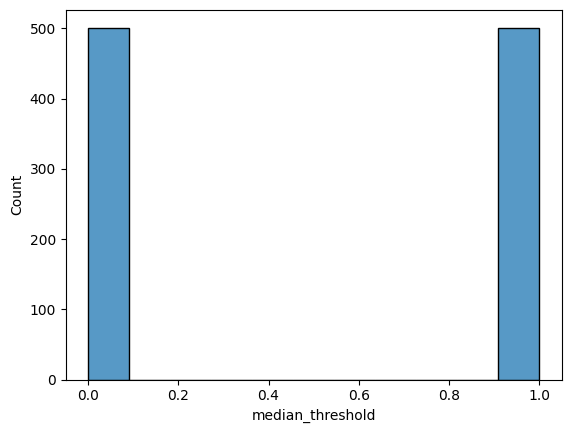

In [4]:
sns.histplot(df['median_threshold'])

In [32]:
X_ic50 = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI', 'median_threshold'])
y_ic50 = df['median_threshold']
X_train, X_test, y_train, y_test = train_test_split(X_ic50, y_ic50, test_size=0.2, random_state=42, stratify=y_ic50)
pipeline = Pipeline([('scaler', StandardScaler()),
                      ('model', LogisticRegression())])
pipeline.fit(X_train, y_train)
pred_train = pipeline.predict(X_train)
pred_test = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

c:\Users\arayd\anaconda3\envs\gpu_cuda\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [6]:
print(confusion_matrix(y_train, pred_train))

[[300 100]
 [ 74 326]]


In [7]:
print(confusion_matrix(y_test, pred_test))

[[61 40]
 [24 76]]


In [8]:
print("LogisticRegression метрики train:")
print(classification_report(y_train, pred_train))
print("LogisticRegression метрики test:")
print(classification_report(y_test, pred_test))

LogisticRegression метрики train:
              precision    recall  f1-score   support

           0       0.80      0.75      0.78       400
           1       0.77      0.81      0.79       400

    accuracy                           0.78       800
   macro avg       0.78      0.78      0.78       800
weighted avg       0.78      0.78      0.78       800

LogisticRegression метрики test:
              precision    recall  f1-score   support

           0       0.72      0.60      0.66       101
           1       0.66      0.76      0.70       100

    accuracy                           0.68       201
   macro avg       0.69      0.68      0.68       201
weighted avg       0.69      0.68      0.68       201



In [9]:
xgb = XGBClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 7, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1],
    'alpha': [0, 0.1, 1],
    'lambda': [1, 5, 10]
}
grid_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=1,
    verbose=1
)
grid_search_xgb.fit(X_train, y_train)
print(f"лучшие параметры: {grid_search_xgb.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
лучшие параметры: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'lambda': 5, 'colsample_bytree': 1, 'alpha': 0.1}


In [10]:
pred_train_xgb = grid_search_xgb.best_estimator_.predict(X_train)
pred_test_xgb = grid_search_xgb.best_estimator_.predict(X_test)
print("XGBClassifier метрики train:")
print(f"{classification_report(y_train, pred_train_xgb)}")
print("XGBClassifier метрики test:")
print(f"{classification_report(y_test, pred_test_xgb)}")

XGBClassifier метрики train:
              precision    recall  f1-score   support

           0       0.82      0.79      0.80       400
           1       0.80      0.82      0.81       400

    accuracy                           0.81       800
   macro avg       0.81      0.81      0.81       800
weighted avg       0.81      0.81      0.81       800

XGBClassifier метрики test:
              precision    recall  f1-score   support

           0       0.77      0.66      0.71       101
           1       0.70      0.80      0.75       100

    accuracy                           0.73       201
   macro avg       0.74      0.73      0.73       201
weighted avg       0.74      0.73      0.73       201



In [11]:
rfc = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}
random_search_rf = RandomizedSearchCV(
    estimator=rfc,
    param_distributions=param_grid_rf,
    n_iter=20,
    cv=3,
    scoring='f1',
    n_jobs=1,
    verbose=1,
    random_state=42
)
random_search_rf.fit(X_train, y_train)
print(f"лучшие параметры: {random_search_rf.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
лучшие параметры: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 7}


In [12]:
pred_train_rf = random_search_rf.best_estimator_.predict(X_train)
pred_test_rf = random_search_rf.best_estimator_.predict(X_test)
print("RandomForestClassifier метрики train:")
print(f"{classification_report(y_train, pred_train_rf)}")
print("RandomForestClassifier метрики test:")
print(f"{classification_report(y_test, pred_test_rf)}")

RandomForestClassifier метрики train:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       400
           1       0.88      0.88      0.88       400

    accuracy                           0.88       800
   macro avg       0.88      0.88      0.88       800
weighted avg       0.88      0.88      0.88       800

RandomForestClassifier метрики test:
              precision    recall  f1-score   support

           0       0.75      0.65      0.70       101
           1       0.69      0.78      0.73       100

    accuracy                           0.72       201
   macro avg       0.72      0.72      0.72       201
weighted avg       0.72      0.72      0.72       201



In [33]:
accuracy_log_train = accuracy_score(y_train, pred_train)
recall_logb_train = recall_score(y_train, pred_train)
precision_log_train = precision_score(y_train, pred_train)
f1_log_train = f1_score(y_train, pred_train)
accuracy_log_test = accuracy_score(y_test, pred_test)
recall_logb_test = recall_score(y_test, pred_test)
precision_log_test = precision_score(y_test, pred_test)
f1_log_test = f1_score(y_test, pred_test)
roc_auc_test = roc_auc_score(y_test, y_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

accuracy_xgb_train = accuracy_score(y_train, pred_train_xgb)
recall_xgb_train = recall_score(y_train, pred_train_xgb)
precision_xgb_train = precision_score(y_train, pred_train_xgb)
f1_xgb_train = f1_score(y_train, pred_train_xgb)
accuracy_xgb_test = accuracy_score(y_test, pred_test_xgb)
recall_xgb_test = recall_score(y_test, pred_test_xgb)
precision_xgb_test = precision_score(y_test, pred_test_xgb)
f1_xgb_test = f1_score(y_test, pred_test_xgb)

accuracy_rf_train = accuracy_score(y_train, pred_train_rf)
recall_rf_train = recall_score(y_train, pred_train_rf)
precision_rf_train = precision_score(y_train, pred_train_rf)
f1_rf_train = f1_score(y_train, pred_train_rf)
accuracy_rf_test = accuracy_score(y_test, pred_test_rf)
recall_rf_test = recall_score(y_test, pred_test_rf)
precision_rf_test = precision_score(y_test, pred_test_rf)
f1_rf_test = f1_score(y_test, pred_test_rf)

In [19]:
df_metrics_train = pd.DataFrame({
    'Model': ['LogRegr', 'XGBoost', 'RandomForest'],
    'Accuracy': [accuracy_log_train, accuracy_xgb_train, accuracy_rf_train],
    'Precision': [precision_log_train, precision_xgb_train, precision_rf_train],
    'Recall': [recall_logb_train, recall_xgb_train, recall_rf_train],
    'f1': [f1_log_train, f1_xgb_train, f1_rf_train]
})

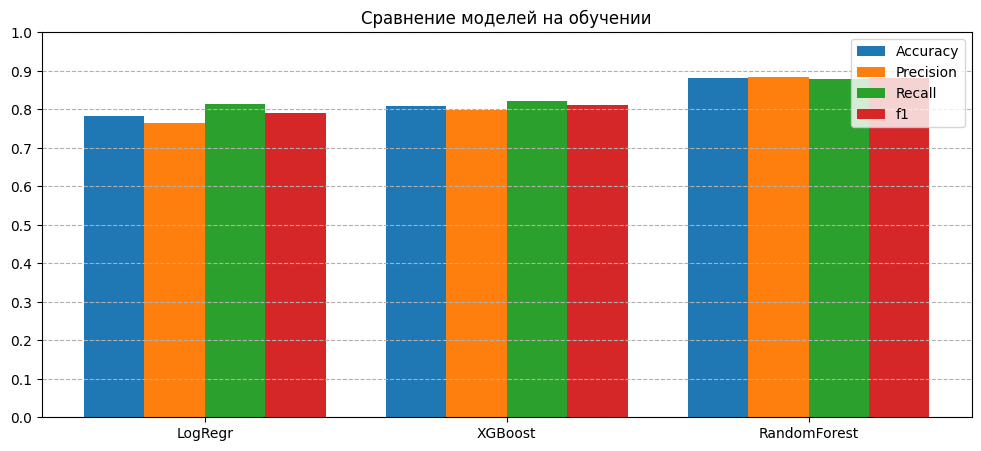

In [28]:
plt.figure(figsize=(12, 5))
width = 0.2
x = np.arange(len(df_metrics_train['Model']))
plt.bar(x - 1.5 * width, df_metrics_train['Accuracy'], width, label='Accuracy')
plt.bar(x - 0.5 * width, df_metrics_train['Precision'], width, label='Precision')
plt.bar(x + 0.5 * width, df_metrics_train['Recall'], width, label='Recall')
plt.bar(x + 1.5 * width, df_metrics_train['f1'], width, label='f1')
plt.xticks(x, df_metrics_train['Model'])
plt.legend()
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(axis='y',linestyle= '--')
plt.title('Сравнение моделей на обучении')
plt.show()

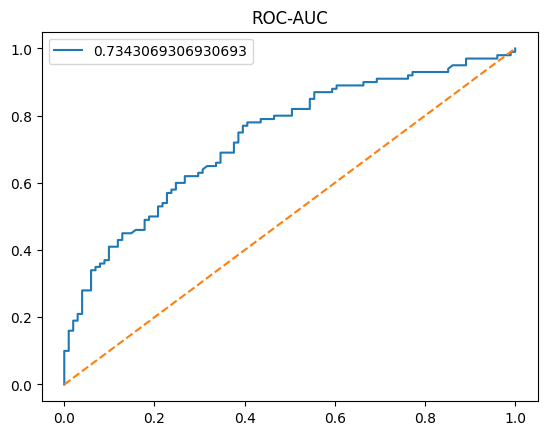

In [38]:
plt.plot(fpr, tpr, label=roc_auc_test)
plt.plot([0, 1], [0, 1], linestyle= '--')
plt.title('ROC-AUC')
plt.legend()
plt.show()